In [4]:
df = pd.read_csv("S002_whole_df.csv")
print(f"Shape: {df.shape}")
print(f"Total duration: {df['TIMESTAMP'].max() / 3600:.2f} hours")
print(f"Sampling rate check: {1 / df['TIMESTAMP'].diff().median():.0f} Hz")
print(f"\nColumns:\n{df.dtypes}")

Shape: (2013697, 14)
Total duration: 8.74 hours
Sampling rate check: 64 Hz

Columns:
TIMESTAMP            float64
BVP                  float64
ACC_X                float64
ACC_Y                float64
ACC_Z                float64
TEMP                 float64
EDA                  float64
HR                   float64
IBI                  float64
Sleep_Stage           object
Obstructive_Apnea    float64
Central_Apnea        float64
Hypopnea             float64
Multiple_Events      float64
dtype: object


In [5]:
stage_counts = df['Sleep_Stage'].value_counts()
stage_seconds = (stage_counts / 64).round(0)  # 64Hz so divide by 64 for seconds
stage_minutes = (stage_seconds / 60).round(1)

summary = pd.DataFrame({
    'Rows': stage_counts,
    'Seconds': stage_seconds,
    'Minutes': stage_minutes
})
print(summary)

               Rows   Seconds  Minutes
Sleep_Stage                           
N2           641280 10020.000  167.000
P            587136  9174.000  152.900
W            508801  7950.000  132.500
R            153600  2400.000   40.000
N1           122880  1920.000   32.000


In [6]:
cols = ['BVP', 'HR', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'IBI']
print("Null counts:")
print(df[cols].isnull().sum())
print("\nBasic stats (excluding P stage):")
sleep_df = df[df['Sleep_Stage'] != 'P']
print(sleep_df[['HR', 'EDA', 'TEMP', 'BVP']].describe().round(2))

Null counts:
BVP         0
HR          0
EDA         0
TEMP        0
ACC_X       0
ACC_Y       0
ACC_Z       0
IBI      1488
dtype: int64

Basic stats (excluding P stage):
               HR         EDA        TEMP         BVP
count 1426561.000 1426561.000 1426561.000 1426561.000
mean       67.900       0.210      34.530       0.000
std         8.470       0.260       1.150     102.440
min        54.520       0.040      32.000   -2135.460
25%        63.030       0.100      33.650     -12.100
50%        65.480       0.140      34.710       0.890
75%        69.970       0.160      35.590      12.630
max       132.480       1.700      36.150    1708.230


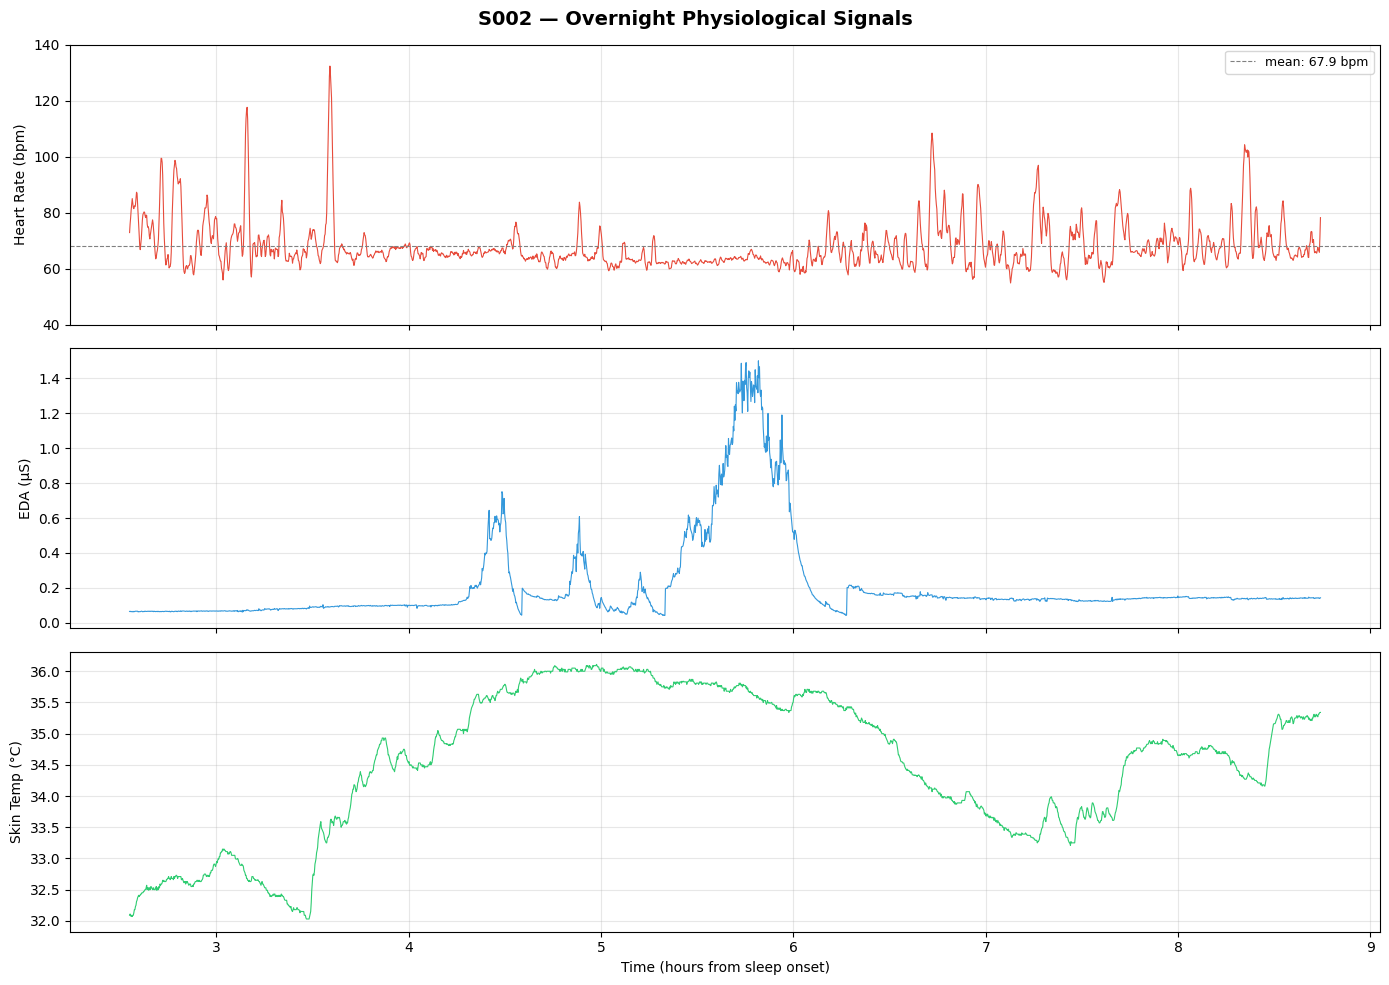

In [7]:
# work only with sleep period (exclude P stage)
sleep_df = df[df['Sleep_Stage'] != 'P'].copy()
sleep_df['time_hours'] = sleep_df['TIMESTAMP'] / 3600

# downsample for plotting — 1 point per 10 seconds (every 640 rows)
plot_df = sleep_df.iloc[::640].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('S002 — Overnight Physiological Signals', fontsize=14, fontweight='bold')

# HR
axes[0].plot(plot_df['time_hours'], plot_df['HR'], color='#e74c3c', linewidth=0.8)
axes[0].set_ylabel('Heart Rate (bpm)')
axes[0].set_ylim(40, 140)
axes[0].axhline(y=plot_df['HR'].mean(), color='gray', linestyle='--', 
                linewidth=0.8, label=f"mean: {plot_df['HR'].mean():.1f} bpm")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# EDA
axes[1].plot(plot_df['time_hours'], plot_df['EDA'], color='#3498db', linewidth=0.8)
axes[1].set_ylabel('EDA (μS)')
axes[1].grid(True, alpha=0.3)

# TEMP
axes[2].plot(plot_df['time_hours'], plot_df['TEMP'], color='#2ecc71', linewidth=0.8)
axes[2].set_ylabel('Skin Temp (°C)')
axes[2].set_xlabel('Time (hours from sleep onset)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

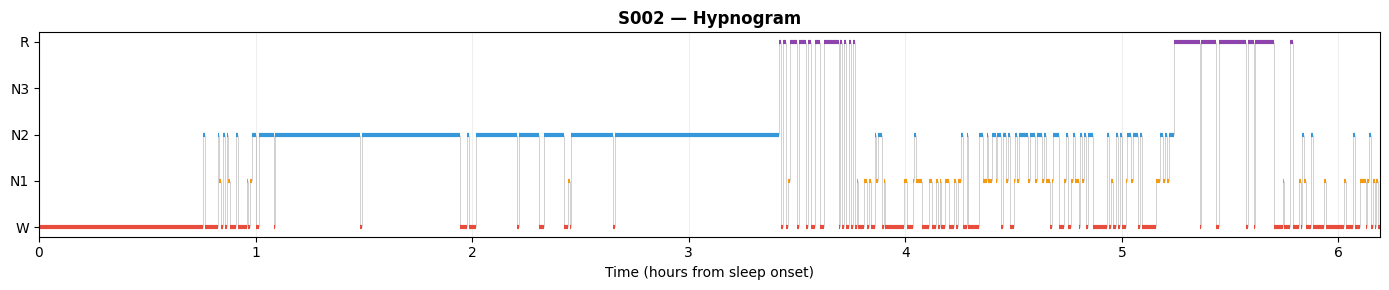

In [9]:
stage_map = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'R': 0}
stage_labels = {4: 'W', 3: 'N1', 2: 'N2', 1: 'N3', 0: 'R'}
stage_colors_line = {'W': '#e74c3c', 'N1': '#f39c12', 
                     'N2': '#3498db', 'N3': '#1a5276', 'R': '#8e44ad'}

# one row per epoch
hypno_df = sleep_df.iloc[::1920].copy().reset_index(drop=True)

# reset time to start at 0
hypno_df['time_hours'] = (hypno_df['TIMESTAMP'] - hypno_df['TIMESTAMP'].min()) / 3600
hypno_df['stage_num'] = hypno_df['Sleep_Stage'].map(stage_map)

fig, ax = plt.subplots(figsize=(14, 3))

# draw as step chart with color per segment
for i in range(len(hypno_df) - 1):
    stage = hypno_df['Sleep_Stage'].iloc[i]
    x_start = hypno_df['time_hours'].iloc[i]
    x_end = hypno_df['time_hours'].iloc[i + 1]
    y = hypno_df['stage_num'].iloc[i]
    ax.hlines(y=y, xmin=x_start, xmax=x_end,
              colors=stage_colors_line.get(stage, 'gray'), linewidth=3)
    ax.vlines(x=x_end,
              ymin=min(y, hypno_df['stage_num'].iloc[i + 1]),
              ymax=max(y, hypno_df['stage_num'].iloc[i + 1]),
              colors='gray', linewidth=0.5, alpha=0.5)

ax.set_yticks(list(stage_labels.keys()))
ax.set_yticklabels(list(stage_labels.values()), fontsize=10)
ax.set_xlabel('Time (hours from sleep onset)')
ax.set_title('S002 — Hypnogram', fontweight='bold')
ax.set_xlim(0, hypno_df['time_hours'].max())
ax.grid(True, alpha=0.2, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
def compute_hr_variability(hr_series):
    # std dev of HR within epoch as HRV proxy
    # more variation = less stable autonomic state
    return hr_series.std()

def compute_movement(acc_x, acc_y, acc_z):
    magnitude = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)
    return magnitude.std()

epochs = []
for epoch_idx, group in sleep_df.groupby('epoch_idx'):
    stage = group['Sleep_Stage'].mode()[0]
    
    epoch = {
        'epoch_idx':    epoch_idx,
        'time_hours':   (group['TIMESTAMP'].iloc[0] - sleep_df['TIMESTAMP'].iloc[0]) / 3600,
        'sleep_stage':  stage,
        'mean_hr':      group['HR'].mean(),
        'hr_std':       compute_hr_variability(group['HR']),
        'movement':     compute_movement(group['ACC_X'], group['ACC_Y'], group['ACC_Z']),
        'eda_mean':     group['EDA'].mean(),
        'temp_mean':    group['TEMP'].mean(),
    }
    epochs.append(epoch)

epochs_df = pd.DataFrame(epochs)

print("HR std (HRV proxy) distribution:")
print(epochs_df['hr_std'].describe().round(3))
print(f"\nMovement percentiles:")
print(epochs_df['movement'].quantile([0.25, 0.50, 0.75, 0.90, 0.95]).round(3))

HR std (HRV proxy) distribution:
count   743.000
mean      1.143
std       1.281
min       0.035
25%       0.333
50%       0.728
75%       1.467
max       9.702
Name: hr_std, dtype: float64

Movement percentiles:
0.250   0.425
0.500   0.542
0.750   1.365
0.900   3.025
0.950   4.630
Name: movement, dtype: float64


In [15]:
def compute_fatigue_score(row):
    score = 0
    
    # sleep stage (40 pts)
    stage_scores = {'W': 40, 'N1': 25, 'N2': 10, 'N3': 5, 'R': 20}
    score += stage_scores.get(row['sleep_stage'], 20)
    
    # HR level (20 pts)
    if row['mean_hr'] > 80:
        score += 20
    elif row['mean_hr'] > 65:
        score += 10
    
    # HR variability — low std = stable/restful, high std = unstable/arousal (20 pts)
    # from distribution: median hr_std is ~0.5, high is >2.0
    if row['hr_std'] > 3.0:
        score += 20
    elif row['hr_std'] > 1.0:
        score += 10
    
    # movement (20 pts) — adjusted threshold from distribution
    if row['movement'] > 2.0:
        score += 20
    elif row['movement'] > 1.0:
        score += 10
    
    return min(score, 100)

epochs_df['fatigue_score'] = epochs_df.apply(compute_fatigue_score, axis=1)

print("Fatigue score distribution:")
print(epochs_df['fatigue_score'].describe().round(1))
print(f"\nBy sleep stage:")
print(epochs_df.groupby('sleep_stage')['fatigue_score'].mean().round(1).sort_values(ascending=False))

Fatigue score distribution:
count   744.000
mean     38.500
std      23.200
min      10.000
25%      20.000
50%      37.500
75%      60.000
max     100.000
Name: fatigue_score, dtype: float64

By sleep stage:
sleep_stage
W    62.100
N1   44.100
R    37.000
N2   19.000
Name: fatigue_score, dtype: float64


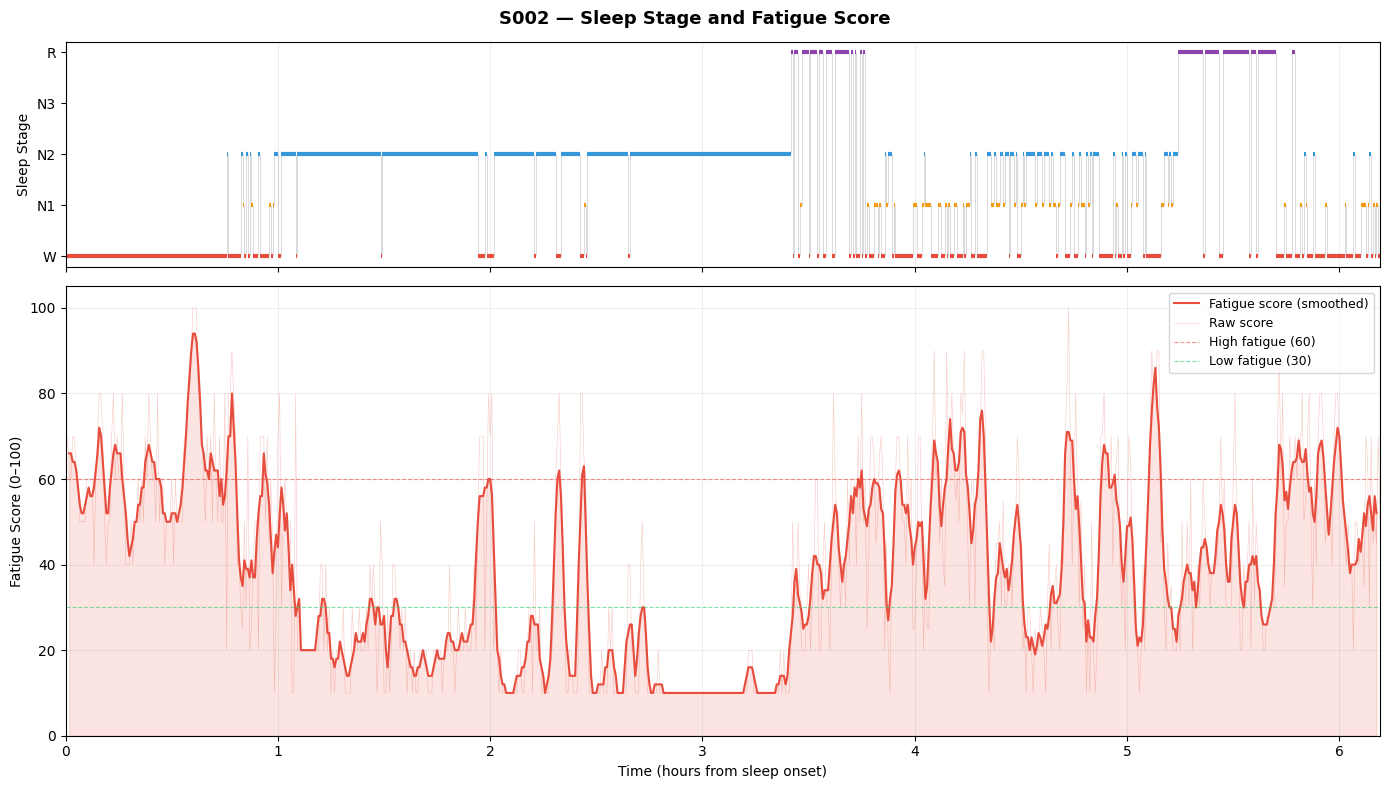

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), 
                          gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle('S002 — Sleep Stage and Fatigue Score', 
             fontsize=13, fontweight='bold')

# ── top panel: hypnogram ──────────────────────────────────────────
stage_map    = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'R': 0}
stage_labels = {4: 'W', 3: 'N1', 2: 'N2', 1: 'N3', 0: 'R'}
stage_colors = {'W': '#e74c3c', 'N1': '#f39c12',
                'N2': '#3498db', 'N3': '#1a5276', 'R': '#8e44ad'}

epochs_df['stage_num'] = epochs_df['sleep_stage'].map(stage_map)

for i in range(len(epochs_df) - 1):
    stage   = epochs_df['sleep_stage'].iloc[i]
    x_start = epochs_df['time_hours'].iloc[i]
    x_end   = epochs_df['time_hours'].iloc[i + 1]
    y       = epochs_df['stage_num'].iloc[i]
    axes[0].hlines(y=y, xmin=x_start, xmax=x_end,
                   colors=stage_colors.get(stage, 'gray'), linewidth=3)
    axes[0].vlines(x=x_end,
                   ymin=min(y, epochs_df['stage_num'].iloc[i + 1]),
                   ymax=max(y, epochs_df['stage_num'].iloc[i + 1]),
                   colors='gray', linewidth=0.5, alpha=0.4)

axes[0].set_yticks(list(stage_labels.keys()))
axes[0].set_yticklabels(list(stage_labels.values()))
axes[0].set_xlim(0, epochs_df['time_hours'].max())
axes[0].set_ylabel('Sleep Stage')
axes[0].grid(True, alpha=0.2, axis='x')
axes[0].invert_yaxis()
axes[0].set_xticklabels([])

# ── bottom panel: fatigue score ───────────────────────────────────
# smooth with rolling average for readability (5-epoch window = 2.5 min)
epochs_df['fatigue_smooth'] = (epochs_df['fatigue_score']
                                .rolling(window=5, center=True)
                                .mean())

axes[1].fill_between(epochs_df['time_hours'], 
                     epochs_df['fatigue_smooth'],
                     alpha=0.15, color='#e74c3c')
axes[1].plot(epochs_df['time_hours'], epochs_df['fatigue_smooth'],
             color='#e74c3c', linewidth=1.5, label='Fatigue score (smoothed)')
axes[1].plot(epochs_df['time_hours'], epochs_df['fatigue_score'],
             color='#e74c3c', linewidth=0.4, alpha=0.3, label='Raw score')

# reference lines
axes[1].axhline(y=60, color='#e74c3c', linestyle='--', 
                linewidth=0.8, alpha=0.6, label='High fatigue (60)')
axes[1].axhline(y=30, color='#2ecc71', linestyle='--', 
                linewidth=0.8, alpha=0.6, label='Low fatigue (30)')

axes[1].set_ylim(0, 105)
axes[1].set_xlim(0, epochs_df['time_hours'].max())
axes[1].set_ylabel('Fatigue Score (0–100)')
axes[1].set_xlabel('Time (hours from sleep onset)')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [17]:
total_epochs    = len(epochs_df)
sleep_epochs    = epochs_df[epochs_df['sleep_stage'] != 'W']
total_sleep_min = len(sleep_epochs) * 0.5  # each epoch = 30s = 0.5 min

rem_pct  = len(epochs_df[epochs_df['sleep_stage'] == 'R'])  / total_epochs * 100
n2_pct   = len(epochs_df[epochs_df['sleep_stage'] == 'N2']) / total_epochs * 100
wake_pct = len(epochs_df[epochs_df['sleep_stage'] == 'W'])  / total_epochs * 100

high_fatigue_pct = len(epochs_df[epochs_df['fatigue_score'] >= 60]) / total_epochs * 100

print("=" * 45)
print("  S002 — Sleep & Fatigue Summary")
print("=" * 45)
print(f"  Total recording:     {epochs_df['time_hours'].max():.1f} hours")
print(f"  Total sleep time:    {total_sleep_min:.0f} min")
print(f"  Wake:                {wake_pct:.1f}%")
print(f"  N1:                  {len(epochs_df[epochs_df['sleep_stage']=='N1'])/total_epochs*100:.1f}%")
print(f"  N2:                  {n2_pct:.1f}%")
print(f"  N3:                  0.0%  (absent)")
print(f"  REM:                 {rem_pct:.1f}%")
print(f"  Avg fatigue score:   {epochs_df['fatigue_score'].mean():.1f} / 100")
print(f"  High fatigue (≥60):  {high_fatigue_pct:.1f}% of night")
print(f"  Avg HR:              {epochs_df['mean_hr'].mean():.1f} bpm")
print("=" * 45)

  S002 — Sleep & Fatigue Summary
  Total recording:     6.2 hours
  Total sleep time:    239 min
  Wake:                35.8%
  N1:                  8.6%
  N2:                  44.9%
  N3:                  0.0%  (absent)
  REM:                 10.8%
  Avg fatigue score:   38.5 / 100
  High fatigue (≥60):  26.6% of night
  Avg HR:              67.9 bpm


In [18]:
# get apnea events — any epoch where at least one event occurred
# the columns have values when an event is present, NaN otherwise
sleep_df['any_apnea'] = (
    sleep_df['Obstructive_Apnea'].notna() |
    sleep_df['Central_Apnea'].notna() |
    sleep_df['Hypopnea'].notna() |
    sleep_df['Multiple_Events'].notna()
)

# aggregate to epoch level — flag epoch if any apnea row within it
apnea_by_epoch = sleep_df.groupby('epoch_idx')['any_apnea'].any().reset_index()
apnea_by_epoch.columns = ['epoch_idx', 'has_apnea']

# merge into epochs_df
epochs_df = epochs_df.merge(apnea_by_epoch, on='epoch_idx', how='left')

print(f"Epochs with apnea events: {epochs_df['has_apnea'].sum()} / {len(epochs_df)}")
print(f"That's {epochs_df['has_apnea'].mean()*100:.1f}% of epochs")
print(f"\nFatigue score — apnea vs no apnea:")
print(epochs_df.groupby('has_apnea')['fatigue_score'].describe().round(1))

Epochs with apnea events: 119 / 744
That's 16.0% of epochs

Fatigue score — apnea vs no apnea:
            count   mean    std    min    25%    50%    75%     max
has_apnea                                                          
False     625.000 38.500 24.000 10.000 20.000 40.000 60.000 100.000
True      119.000 38.400 18.200 10.000 25.000 35.000 50.000  90.000


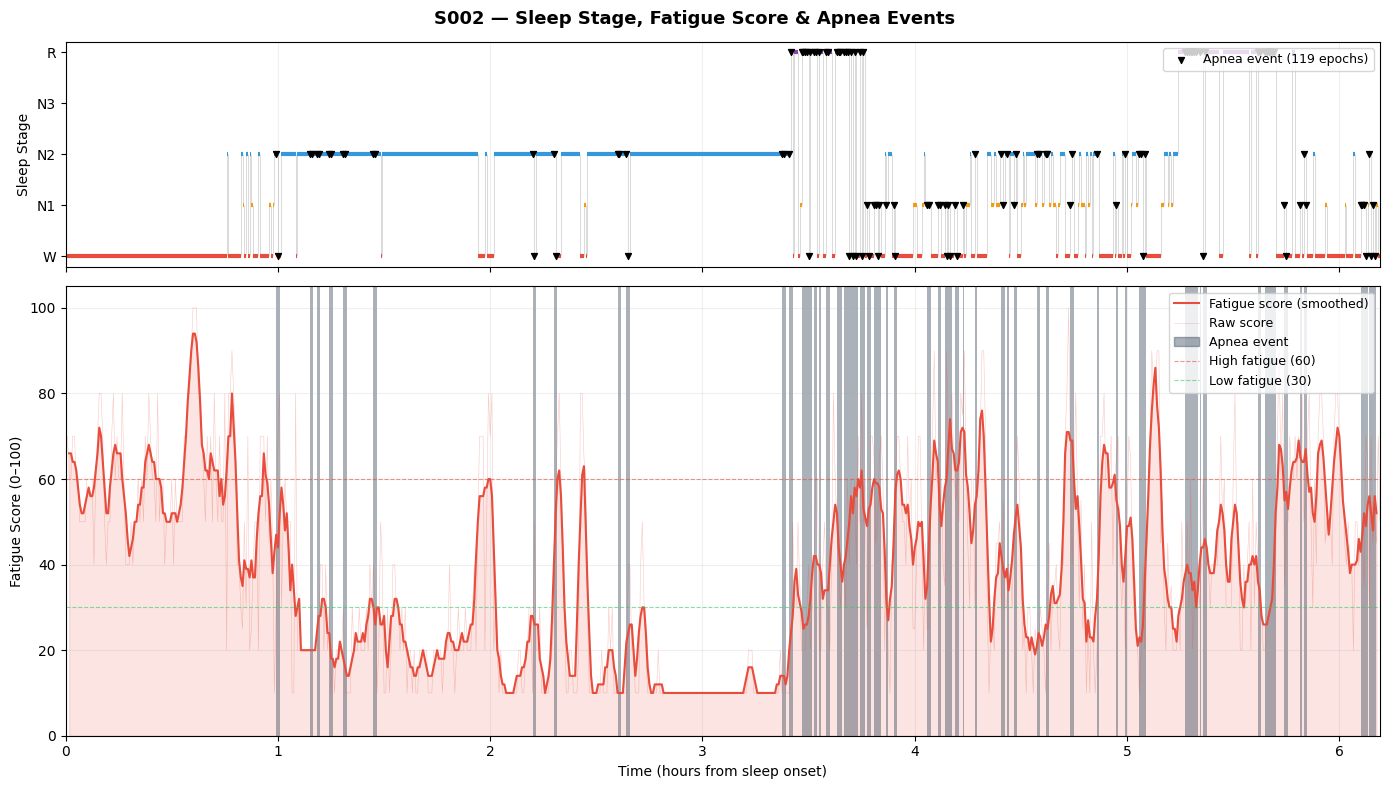

Plot saved as S002_fatigue_dashboard.png


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle('S002 — Sleep Stage, Fatigue Score & Apnea Events',
             fontsize=13, fontweight='bold')

# ── top panel: hypnogram ──────────────────────────────────────────
stage_map    = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'R': 0}
stage_labels = {4: 'W', 3: 'N1', 2: 'N2', 1: 'N3', 0: 'R'}
stage_colors = {'W': '#e74c3c', 'N1': '#f39c12',
                'N2': '#3498db', 'N3': '#1a5276', 'R': '#8e44ad'}

epochs_df['stage_num'] = epochs_df['sleep_stage'].map(stage_map)

for i in range(len(epochs_df) - 1):
    stage   = epochs_df['sleep_stage'].iloc[i]
    x_start = epochs_df['time_hours'].iloc[i]
    x_end   = epochs_df['time_hours'].iloc[i + 1]
    y       = epochs_df['stage_num'].iloc[i]
    axes[0].hlines(y=y, xmin=x_start, xmax=x_end,
                   colors=stage_colors.get(stage, 'gray'), linewidth=3)
    axes[0].vlines(x=x_end,
                   ymin=min(y, epochs_df['stage_num'].iloc[i + 1]),
                   ymax=max(y, epochs_df['stage_num'].iloc[i + 1]),
                   colors='gray', linewidth=0.5, alpha=0.4)

# apnea markers on hypnogram
apnea_epochs = epochs_df[epochs_df['has_apnea'] == True]
axes[0].scatter(apnea_epochs['time_hours'],
                apnea_epochs['stage_num'],
                marker='v', color='black', s=18, zorder=5,
                label=f'Apnea event ({len(apnea_epochs)} epochs)')

axes[0].set_yticks(list(stage_labels.keys()))
axes[0].set_yticklabels(list(stage_labels.values()))
axes[0].set_xlim(0, epochs_df['time_hours'].max())
axes[0].set_ylabel('Sleep Stage')
axes[0].grid(True, alpha=0.2, axis='x')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xticklabels([])

# ── bottom panel: fatigue score + apnea shading ───────────────────
axes[1].fill_between(epochs_df['time_hours'],
                     epochs_df['fatigue_smooth'],
                     alpha=0.15, color='#e74c3c')
axes[1].plot(epochs_df['time_hours'], epochs_df['fatigue_smooth'],
             color='#e74c3c', linewidth=1.5, label='Fatigue score (smoothed)')
axes[1].plot(epochs_df['time_hours'], epochs_df['fatigue_score'],
             color='#e74c3c', linewidth=0.4, alpha=0.3, label='Raw score')

# shade apnea epochs on fatigue panel
for _, row in apnea_epochs.iterrows():
    axes[1].axvspan(row['time_hours'],
                    row['time_hours'] + 0.5/60,
                    alpha=0.4, color='#2c3e50', linewidth=0)

# dummy patch for legend
from matplotlib.patches import Patch
apnea_patch = Patch(color='#2c3e50', alpha=0.4, label='Apnea event')

axes[1].axhline(y=60, color='#e74c3c', linestyle='--',
                linewidth=0.8, alpha=0.6, label='High fatigue (60)')
axes[1].axhline(y=30, color='#2ecc71', linestyle='--',
                linewidth=0.8, alpha=0.6, label='Low fatigue (30)')

axes[1].set_ylim(0, 105)
axes[1].set_xlim(0, epochs_df['time_hours'].max())
axes[1].set_ylabel('Fatigue Score (0–100)')
axes[1].set_xlabel('Time (hours from sleep onset)')
axes[1].legend(handles=[
    axes[1].lines[0], axes[1].lines[1],
    apnea_patch,
    axes[1].lines[2], axes[1].lines[3]
], fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('S002_fatigue_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as S002_fatigue_dashboard.png")

## Summary and Interpretation

### Dataset
This analysis uses the DREAMT dataset v2.1 (Wang et al., 2025), hosted on 
PhysioNet. Specifically, the **data_64Hz** folder is used, which contains 
only the Empatica E4 wristband signals, no PSG signals. Each participant's 
data is provided as a single pre-aligned CSV (`S{id}_whole_df.csv`) containing 
all signals time-aligned at 64Hz:

| Signal | Description | Sample Rate |
|--------|-------------|-------------|
| BVP | Blood volume pulse (PPG) | 64 Hz |
| ACC_X/Y/Z | Triaxial accelerometry | 32 Hz (upsampled to 64Hz in CSV) |
| EDA | Electrodermal activity | 4 Hz (upsampled to 64Hz in CSV) |
| TEMP | Skin temperature | 4 Hz (upsampled to 64Hz in CSV) |
| HR | Heart rate (derived from BVP) | 1 Hz (upsampled to 64Hz in CSV) |
| IBI | Inter-beat interval (derived from BVP) | Sparse, event-driven |
| Sleep_Stage | PSG-annotated label | 1 per 30-second epoch |

At 64Hz, each 30-second epoch corresponds to 1,920 rows. The dataset also 
includes apnea event columns (Obstructive_Apnea, Central_Apnea, Hypopnea, 
Multiple_Events) derived from concurrent PSG recording.

The data_100Hz folder, which contains both E4 and full PSG signals resampled 
to 100Hz, is not used at this stage — it will be relevant for model validation 
against gold-standard EEG-based sleep staging in future work.

---

### Participant S002
This analysis examines one overnight recording from the DREAMT dataset 
(Empatica E4 wristband + PSG labels). Participant S002 has moderate-to-severe 
obstructive sleep apnea (AHI = 22.1/hr).

### Key findings
- **Total recording:** 6.2 hours. Actual sleep time: 239 minutes (~4 hours)
- **Sleep architecture is severely disrupted:** 35.8% of the night spent 
  awake, no slow-wave sleep (N3) recorded, and only 10.8% REM 
  (normal is ~20–25%)
- **Apnea events affect 16% of epochs** (119/744), concentrated in the 
  second half of the night during lighter sleep stages
- **Fatigue score** ranges 10–100 across the night. The lowest scores 
  (10–20) occur during the consolidated N2 block at hours 1.5–3.5 — the 
  most restorative period of the night. The score rises sharply after 
  hour 3.5 as sleep becomes fragmented.
- **26.6% of the night** exceeds the high-fatigue threshold (score ≥ 60)

---

### Fatigue score methodology

The fatigue score (0–100) is computed per 30-second epoch using a rule-based 
heuristic. It is not a trained machine learning model. The score combines four 
physiological features, each grounded in the sleep and fatigue literature:

**Sleep stage (0–40 points)**  
The base contribution reflects how restorative each sleep stage is, drawing on 
Borbely et al.'s two-process model of sleep regulation. Wakefulness contributes 
40 points (no recovery), N1 contributes 25 (light, easily disrupted), REM 
contributes 20 (cognitive restoration but light sleep), N2 contributes 10 
(consolidated, moderately restorative), and N3 would contribute 5 (most 
restorative — absent in this participant).

**Mean heart rate (0–20 points)**  
Elevated resting HR during sleep indicates sympathetic nervous system activity 
rather than the parasympathetic dominance associated with recovery. Epochs with 
mean HR above 80 bpm score 20 points; 65–80 bpm score 10; below 65 score 0. 
Thresholds are based on normal resting sleep HR ranges reviewed in Borghini 
et al. (2014).

**HR variability — std dev within epoch (0–20 points)**  
Low HRV during sleep reflects reduced parasympathetic tone, a marker of 
physiological stress and fatigue (Fan et al., 2024). We use the standard 
deviation of HR within each 30-second epoch as a proxy for HRV, since the 
IBI signal in DREAMT was too sparse for standard RMSSD computation at the 
epoch level. Epochs with HR std dev above 3.0 score 20 points; 1.0–3.0 score 
10; below 1.0 score 0. Thresholds were set by inspecting the observed 
distribution (median = 0.73, 75th percentile = 1.47).

**Accelerometer movement (0–20 points)**  
High physical movement during sleep indicates fragmented, disrupted sleep, the same principle underlying actigraphy-based sleep monitoring (Birrer et al., 2024). We compute the standard deviation of ACC vector magnitude (√(x² + y² + z²)) per epoch. Epochs above 2.0 score 20 points; 1.0–2.0 score 10 below 1.0 score 0. Thresholds were calibrated to the observed distribution in this dataset (median = 0.54, 90th percentile = 3.03) rather than using 
generic defaults.

The four components are summed and clamped to [0, 100]. Component weights 
(40/20/20/20) reflect the primacy of sleep stage as the most direct indicator 
of fatigue recovery, consistent with its central role in biomathematical fatigue 
models such as SAFTE.

---

### Model limitations and next steps

**Current limitations:**
- Apnea events do not directly raise the fatigue score in the current model. 
  Their effect is indirect, apnea causes arousal, arousal changes the sleep 
  stage to W, and W raises the score. The mean fatigue score for apnea epochs 
  (38.4) and non-apnea epochs (38.5) being nearly identical confirms this. A 
  future improvement would add an explicit apnea event penalty.
- The IBI column was too sparse for standard RMSSD computation at epoch level, 
  requiring a cruder HR std dev proxy for HRV. Peak detection on the raw BVP 
  signal would yield proper beat-to-beat intervals and enable true RMSSD.
- Thresholds are set from population norms and this single participant's 
  distributions, they have not been validated against ground-truth fatigue 
  measures or across multiple participants.
- This analysis covers one participant. Conclusions about the model's 
  generalisability cannot be drawn from a single case.

**Next steps:**
1. Run the same pipeline on additional participants with varying AHI severity 
   to assess whether fatigue score patterns differ meaningfully across 
   apnea severity levels
2. Implement proper RMSSD from BVP peak detection to replace the HR std dev proxy
3. Add an explicit apnea event weighting to the fatigue heuristic
4. Compare fatigue score distributions across participants as a precursor to 
   training a supervised classifier